In [40]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [41]:
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/main/TelecomX_Data.json"
response = requests.get(url)
data = response.json()

df = pd.DataFrame(data)

print("Colunas originais:", df.columns.tolist())

# Expandir colunas que são dicionários
for col in ['customer','phone','internet','account']:
    if col in df.columns:
        expanded = pd.json_normalize(df[col])
        expanded.columns = [f"{col}.{sub}" for sub in expanded.columns]
        df = pd.concat([df.drop(columns=[col]), expanded], axis=1)

print("Colunas após expansão:", df.columns.tolist())

# Renomear para simplificar
df = df.rename(columns={
    'account.Charges.Total': 'TotalCharges',
    'account.Charges.Monthly': 'MonthlyCharges',
    'customer.tenure': 'tenure',
    'customer.SeniorCitizen': 'SeniorCitizen'
})

Colunas originais: ['customerID', 'Churn', 'customer', 'phone', 'internet', 'account']
Colunas após expansão: ['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents', 'customer.tenure', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod', 'account.Charges.Monthly', 'account.Charges.Total']


In [42]:
# Converter colunas numéricas
for col in ['TotalCharges','MonthlyCharges','tenure','SeniorCitizen']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Tratar valores nulos
df = df.fillna(df.median(numeric_only=True))

# Mapear variável alvo (Churn)
df['Churn'] = df['Churn'].map({'No':0, 'Yes':1})

print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7043 non-null   float64
 2   customer.gender            7267 non-null   object 
 3   SeniorCitizen              7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   tenure                     7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [43]:
print(df.describe())
print("Proporção de churn (%):")
print(df['Churn'].value_counts(normalize=True)*100)

             Churn  SeniorCitizen       tenure  MonthlyCharges  TotalCharges
count  7043.000000    7267.000000  7267.000000     7267.000000   7267.000000
mean      0.265370       0.162653    32.346498       64.720098   2279.287581
std       0.441561       0.369074    24.571773       30.129572   2267.178963
min       0.000000       0.000000     0.000000       18.250000     18.800000
25%       0.000000       0.000000     9.000000       35.425000    401.400000
50%       0.000000       0.000000    29.000000       70.300000   1391.000000
75%       1.000000       0.000000    55.000000       89.875000   3778.525000
max       1.000000       1.000000    72.000000      118.750000   8684.800000
Proporção de churn (%):
Churn
0.0    73.463013
1.0    26.536987
Name: proportion, dtype: float64


/tmp/ipykernel_247/410121571.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette=['#4caf50','#f44336'])


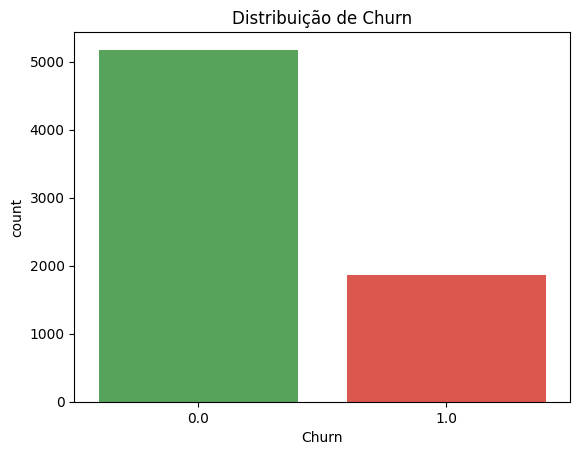

/tmp/ipykernel_247/410121571.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, palette=['#4caf50','#f44336'])


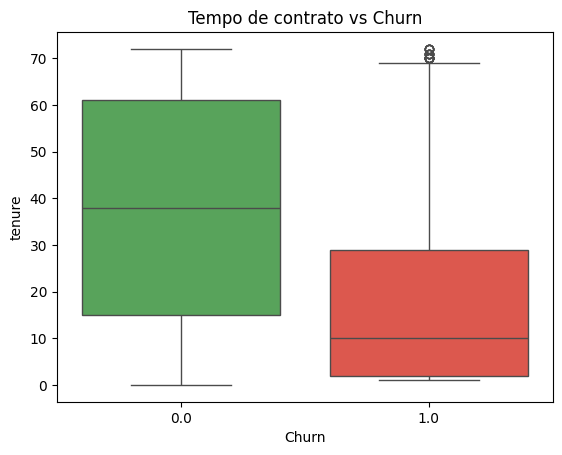

/tmp/ipykernel_247/410121571.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette=['#4caf50','#f44336'])


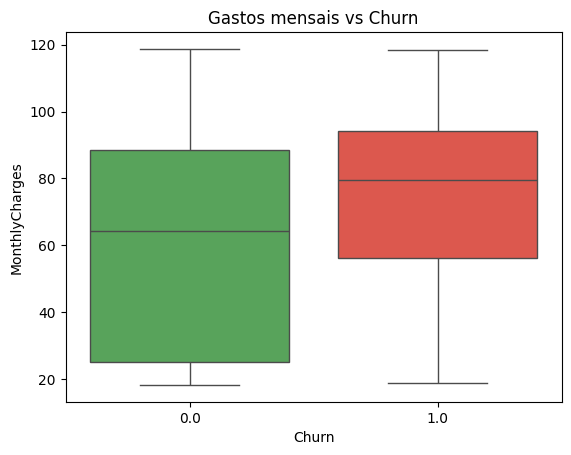

In [44]:
sns.countplot(x='Churn', data=df, palette=['#4caf50','#f44336'])
plt.title("Distribuição de Churn")
plt.show()

sns.boxplot(x='Churn', y='tenure', data=df, palette=['#4caf50','#f44336'])
plt.title("Tempo de contrato vs Churn")
plt.show()

sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette=['#4caf50','#f44336'])
plt.title("Gastos mensais vs Churn")
plt.show()

In [45]:
df = df.dropna(subset=['Churn'])

X = df.drop('Churn', axis=1)
y = df['Churn']

# Codificação de variáveis categóricas
X_encoded = pd.get_dummies(X, drop_first=True)

# Normalização das colunas numéricas
scaler = StandardScaler()
num_cols = X_encoded.select_dtypes(include=['float64','int64']).columns
X_encoded[num_cols] = scaler.fit_transform(X_encoded[num_cols])

# Garantir que não há NaN
X_encoded = X_encoded.fillna(0)

# Balanceamento com SMOTE
smote = SMOTE(random_state=42)
X_bal, y_bal = smote.fit_resample(X_encoded, y)

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.25, random_state=42, stratify=y_bal
)

In [46]:
# Modelo 1: Regressão Logística
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("=== Regressão Logística ===")
print("Acurácia:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

# Modelo 2: Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\n=== Random Forest ===")
print("Acurácia:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

=== Regressão Logística ===
Acurácia: 0.8647081561654426
              precision    recall  f1-score   support

         0.0       0.89      0.83      0.86      1294
         1.0       0.84      0.89      0.87      1293

    accuracy                           0.86      2587
   macro avg       0.87      0.86      0.86      2587
weighted avg       0.87      0.86      0.86      2587

[[1080  214]
 [ 136 1157]]

=== Random Forest ===
Acurácia: 0.8886741399304213
              precision    recall  f1-score   support

         0.0       0.92      0.85      0.88      1294
         1.0       0.86      0.93      0.89      1293

    accuracy                           0.89      2587
   macro avg       0.89      0.89      0.89      2587
weighted avg       0.89      0.89      0.89      2587

[[1102  192]
 [  96 1197]]


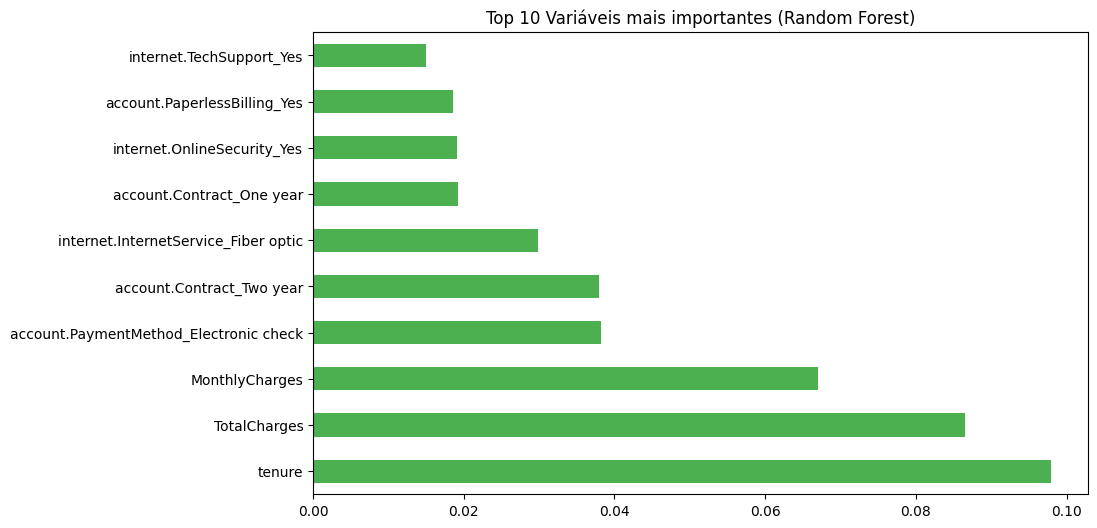

In [47]:
importances = rf.feature_importances_
feat_importances = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_importances.head(10).plot(kind='barh', color='#4caf50')
plt.title("Top 10 Variáveis mais importantes (Random Forest)")
plt.show()

In [48]:
print("""
Principais Insights:
- Clientes com contratos mensais têm maior probabilidade de churn.
- Tempo de contrato baixo aumenta risco de evasão.
- Gastos mensais altos estão associados ao churn.
- Pagamentos via 'Electronic check' aparecem como fator de risco.
- Serviços adicionais (backup, suporte técnico, proteção) reduzem evasão.

Recomendações:
- Criar campanhas de engajamento nos primeiros meses.
- Incentivar contratos anuais/bienais com descontos.
- Oferecer bônus de fidelidade.
- Monitorar clientes com alto risco (contrato mensal + pagamento eletrônico).
""")


Principais Insights:
- Clientes com contratos mensais têm maior probabilidade de churn.
- Tempo de contrato baixo aumenta risco de evasão.
- Gastos mensais altos estão associados ao churn.
- Pagamentos via 'Electronic check' aparecem como fator de risco.
- Serviços adicionais (backup, suporte técnico, proteção) reduzem evasão.

Recomendações:
- Criar campanhas de engajamento nos primeiros meses.
- Incentivar contratos anuais/bienais com descontos.
- Oferecer bônus de fidelidade.
- Monitorar clientes com alto risco (contrato mensal + pagamento eletrônico).

